# 🧠 AI-Based Segmentation and Analysis of Brain MRI (Python version)
This notebook replicates the MATLAB example using Python libraries like `nibabel`, `nilearn`, `scikit-image`, and `matplotlib`. It performs segmentation, filtering, visualization, and voxel counting.

In [73]:
!pip install nibabel nilearn scikit-image matplotlib scipy pandas scikit-learn --quiet

## 1️⃣ Load MRI Volume

In [74]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from skimage import morphology
from scipy.ndimage import label
import pandas as pd 
from skimage import filters, segmentation, morphology, exposure
import matplotlib.colors as mcolors

In [75]:
anat_path = "/kaggle/input/brain-segdata-anat/HC_001_procimg.nii"

try:
    img = nib.load(anat_path)
    data = img.get_fdata()
    affine = img.affine
    print("Image loaded successfully with shape:", data.shape)
except Exception as e:
    print("Could not load NIfTI image. Error:", e)

Image loaded successfully with shape: (256, 256, 128)


## 2️⃣ Visualize Original MRI Slices

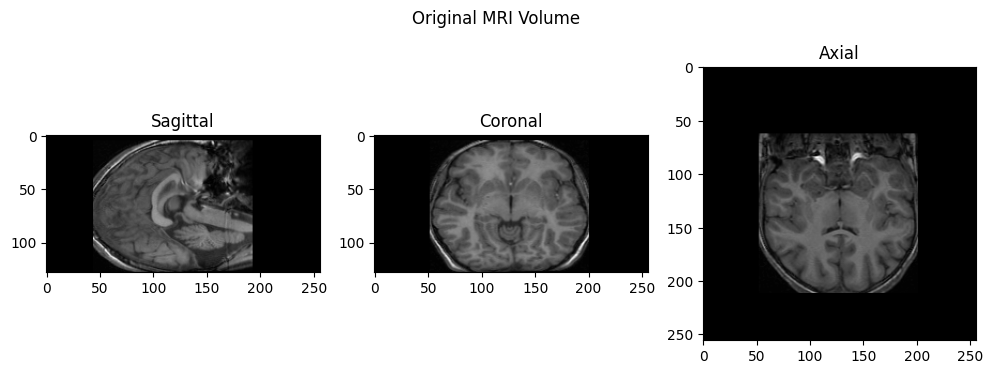

In [76]:
def show_slices(volume, title=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    slices = [volume.shape[0]//2, volume.shape[1]//2, volume.shape[2]//2]
    axes[0].imshow(np.rot90(volume[slices[0], :, :]), cmap="gray"); axes[0].set_title("Sagittal")
    axes[1].imshow(np.rot90(volume[:, slices[1], :]), cmap="gray"); axes[1].set_title("Coronal")
    axes[2].imshow(np.rot90(volume[:, :, slices[2]]), cmap="gray"); axes[2].set_title("Axial")
    if title: fig.suptitle(title)
    plt.show()

show_slices(data, "Original MRI Volume")

## 3️⃣ Segment Using KMeans (Intensity Clustering)

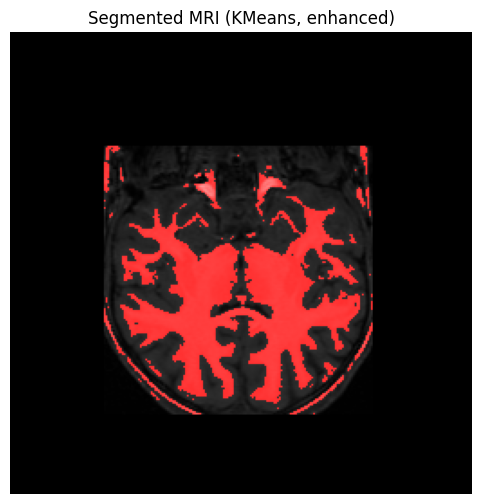

In [77]:
# Normalize intensities
data_norm = (data - data.min()) / (data.max() - data.min())

flat = data_norm.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(flat)
segmented = kmeans.labels_.reshape(data_norm.shape)

# Select the cluster with higher intensity
means = [data_norm[segmented == i].mean() for i in range(3)]
target_cluster = np.argmax(means)
mask = (segmented == target_cluster).astype(np.uint8)

# Show outputs
slice_idx = data.shape[2] // 2
overlay = np.stack([data_norm[:, :, slice_idx]]*3, axis=-1)
overlay[..., 0][mask[:, :, slice_idx] == 1] = 1 

plt.figure(figsize=(6,6))
plt.imshow(np.rot90(overlay))
plt.title("Segmented MRI (KMeans, enhanced)")
plt.axis("off")
plt.show()

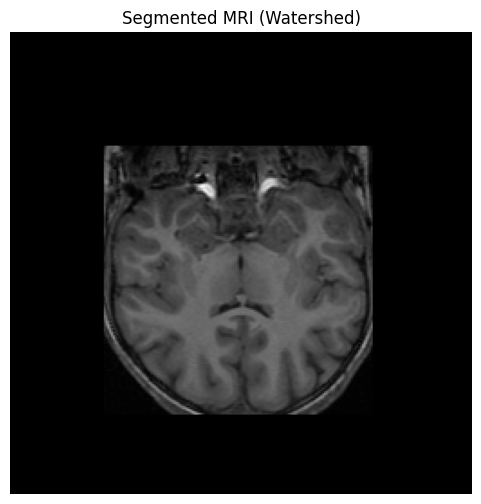

In [78]:
data_norm = (data - data.min()) / (data.max() - data.min())

slice_idx = data_norm.shape[2] // 2
slice_2d = data_norm[:, :, slice_idx]

# Reduce the noise
smooth = filters.gaussian(slice_2d, sigma=1)

gradient = filters.sobel(smooth)

# Create borders
markers = np.zeros_like(smooth, dtype=np.int32)
markers[smooth < 0.3] = 1   
markers[smooth > 0.6] = 2 

# Apply watershed
labels_ws = segmentation.watershed(gradient, markers)

# Create a final mask
mask_ws = labels_ws == 2

# show results
plt.figure(figsize=(6, 6))
plt.imshow(np.rot90(slice_2d), cmap='gray')
plt.contour(np.rot90(mask_ws), colors='r')
plt.title("Segmented MRI (Watershed)")
plt.axis("off")
plt.show()

## 4️⃣ Filter Noisy Voxels (Equivalent to filterNoisyVoxels in MATLAB)

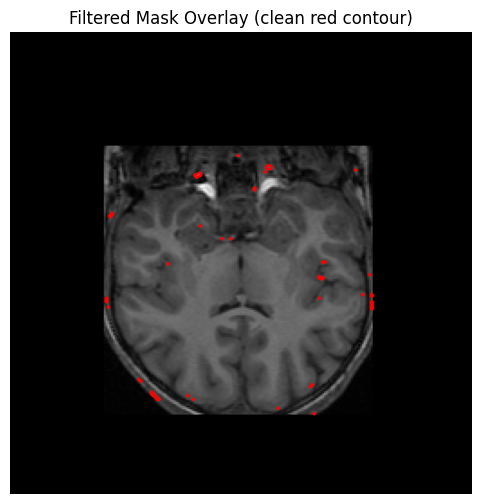

In [79]:
def filter_noisy_voxels(mask, min_voxels=500):
    labeled, n = label(mask)
    counts = np.bincount(labeled.ravel())
    clean_mask = np.zeros_like(mask)
    for i, c in enumerate(counts):
        if c >= min_voxels:
            clean_mask[labeled == i] = 1
    return clean_mask.astype(np.uint8)

mask_filtered = filter_noisy_voxels(mask)

slice_idx = data.shape[2] // 2
plt.figure(figsize=(6,6))
plt.imshow(np.rot90(data_norm[:, :, slice_idx]), cmap='gray')
plt.contour(np.rot90(mask_filtered[:, :, slice_idx]), colors='r', linewidths=0.5)
plt.title("Filtered Mask Overlay (clean red contour)")
plt.axis("off")
plt.show()

## 5️⃣ Visualize Coloured Segmentation

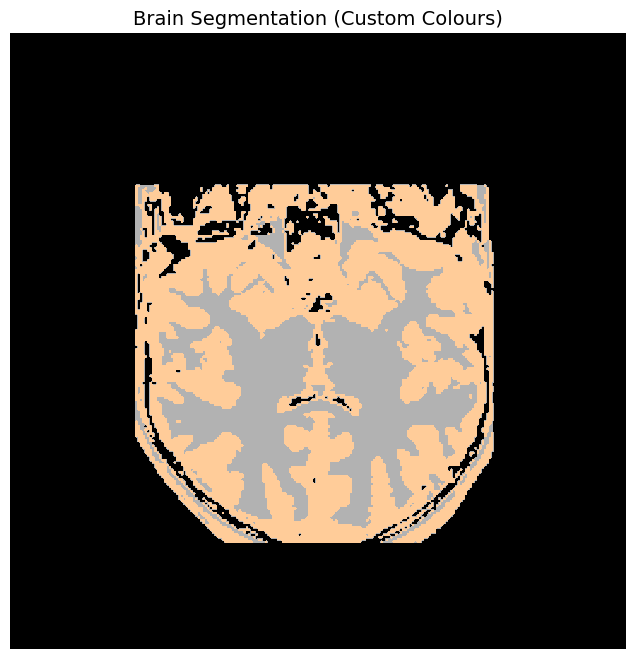

In [80]:
cmap_brain = mcolors.ListedColormap([
    (0, 0, 0),          # black (background)
    (0.7, 0.7, 0.7),    # Light grey (grey substance )
    (1.0, 0.8, 0.6)     # beige (white substance)
])

plt.figure(figsize=(8, 8))
plt.imshow(np.rot90(segmented[:, :, segmented.shape[2]//2]), cmap=cmap_brain)
plt.title('Brain Segmentation (Custom Colours)', fontsize=14)
plt.axis('off')
plt.show()

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:771: UserWarning:





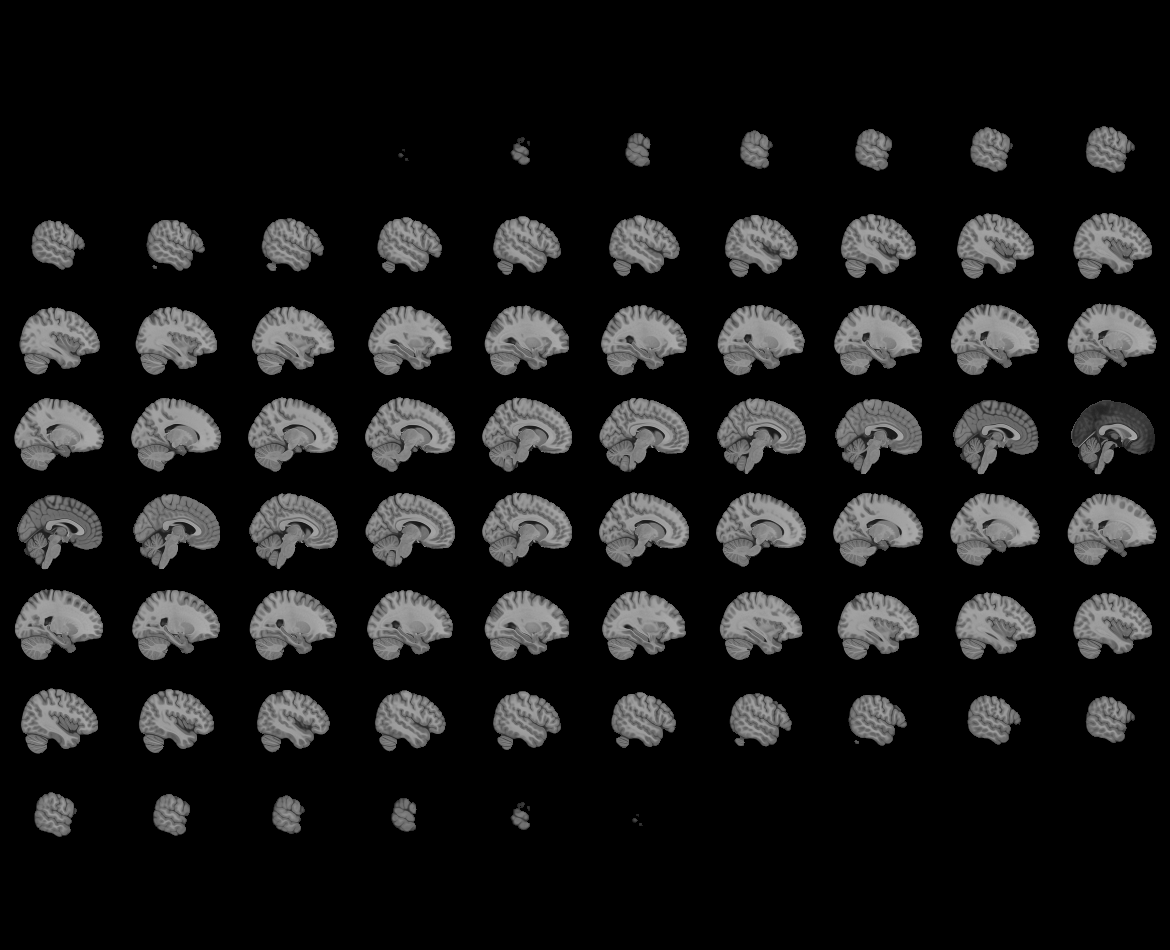
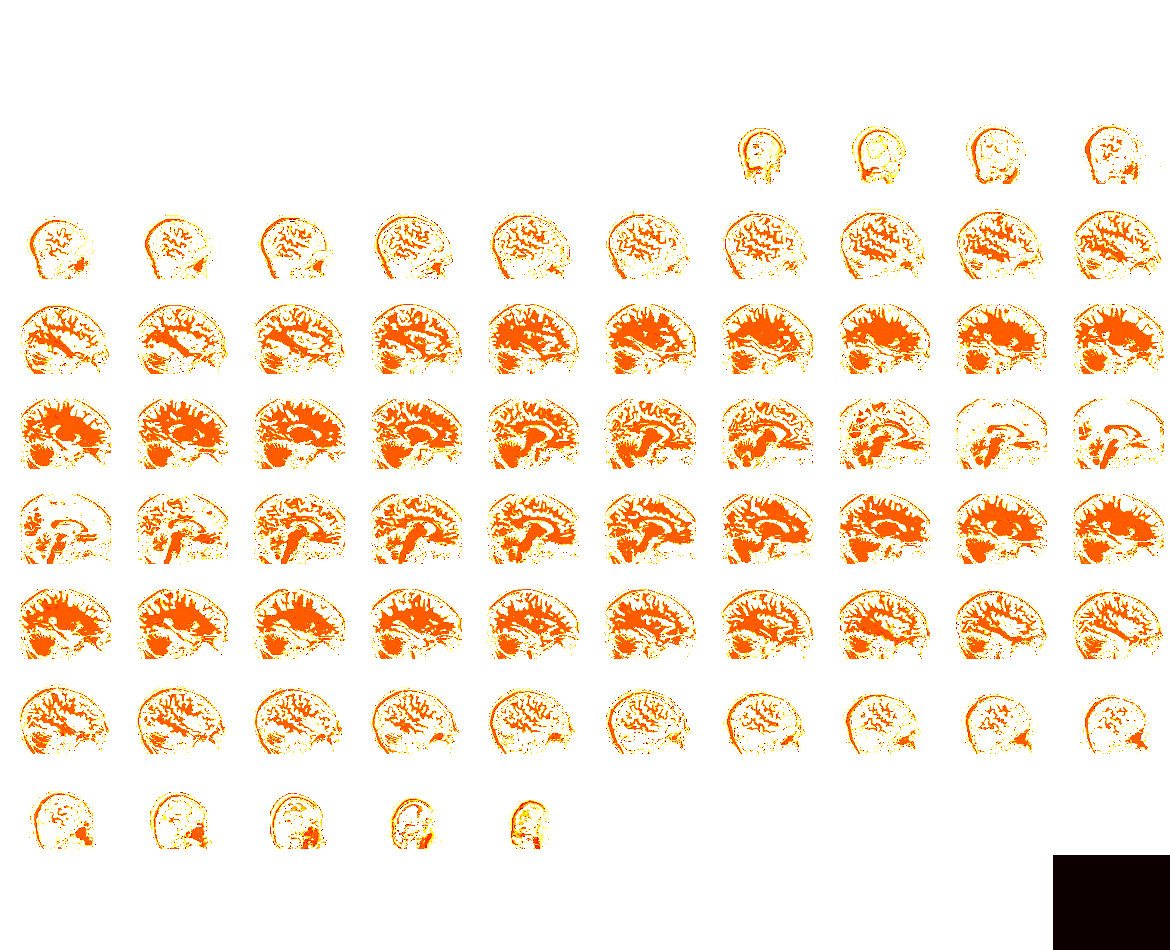

In [81]:
# Converts the NIfTI object to 3D visualization
seg_img = nib.Nifti1Image(segmented.astype(float), affine)

# Interactive View
plotting.view_img(
    seg_img,
    threshold=0.5,
    title="3D Brain Segmentation (Interactive)"
)

## Count Voxels per Label

In [82]:
labels, counts = np.unique(segmented, return_counts=True)
df_voxels = pd.DataFrame({'Label': labels, 'VoxelCount': counts})
df_voxels = df_voxels[df_voxels['Label'] != 0]
print(df_voxels)

   Label  VoxelCount
1      1      693415
2      2     1038674


## Save Outputs

In [83]:

nib.save(nib.Nifti1Image(mask_filtered.astype(np.uint8), affine), "brainSeg_mask_python.nii.gz")
df_voxels.to_csv("segmentation_summary.csv", index=False)
print("Saved segmentation mask and voxel summary.")

Saved segmentation mask and voxel summary.
